In [112]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/all unlabeled/oral_normal_3080.jpg
/kaggle/input/all unlabeled/oral_normal_3357.jpg
/kaggle/input/all unlabeled/oral_normal_0983.jpg
/kaggle/input/all unlabeled/oral_normal_1124.jpg
/kaggle/input/all unlabeled/oral_normal_3829.jpg
/kaggle/input/all unlabeled/oral_normal_3515.jpg
/kaggle/input/all unlabeled/oral_normal_1324.jpg
/kaggle/input/all unlabeled/oral_normal_4162.jpg
/kaggle/input/all unlabeled/oral_scc_0771.jpg
/kaggle/input/all unlabeled/oral_scc_0707.jpg
/kaggle/input/all unlabeled/oral_scc_3093.jpg
/kaggle/input/all unlabeled/oral_normal_0952.jpg
/kaggle/input/all unlabeled/oral_normal_4147.jpg
/kaggle/input/all unlabeled/oral_scc_0480.jpg
/kaggle/input/all unlabeled/oral_scc_0654.jpg
/kaggle/input/all unlabeled/oral_normal_1627.jpg
/kaggle/input/all unlabeled/oral_scc_0620.jpg
/kaggle/input/all unlabeled/oral_normal_1034.jpg
/kaggle/input/all unlabeled/oral_scc_3567.jpg
/kaggle/input/all unlabeled/oral_scc_1208.jpg
/kaggle/input/all unlabeled/oral_scc_0761.jp

In [113]:
!pip install torch torchvision matplotlib numpy tqdm

In [114]:
! pip install efficientnet_pytorch

In [115]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.manifold import TSNE
from torch.cuda.amp import autocast, GradScaler
import os
import torch.optim as optim
from efficientnet_pytorch import EfficientNet  # pip install efficientnet_pytorch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier

In [116]:
# Set environment to reduce memory fragmentation
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [117]:
# Set random seed for reproducibility
torch.manual_seed(42)

In [118]:
# Custom Dataset for Unlabeled Images (with two augmentations)
class OralCancerDataset(Dataset):
    def __init__(self, image_paths, transform1, transform2):
        self.image_paths = image_paths
        self.transform1 = transform1
        self.transform2 = transform2

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        view1 = self.transform1(image)
        view2 = self.transform2(image)
        return view1, view2

In [119]:
# Define wrapper for downstream task (single image + label) - Simplified since base uses None transform
class DownstreamWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        item = self.subset[idx]
        if len(item) == 3:  # From aug dataset, ignore img2
            img, _, label = item
        else:  # From base (PIL, label)
            img, label = item
        if self.transform:
            img = self.transform(img)
        return img, label

In [120]:
# Projector MLP
class Projector(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

In [121]:
# Define SimCLR model
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super(SimCLR, self).__init__()
        self.encoder = base_encoder
        self.encoder.classifier = nn.Identity()  # Remove the final classifier to get 1280 features
        self.feature_dim = 1280  # EfficientNet-B0 feature dim after avgpool
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )
    
    def forward(self, x):
        h = self.encoder(x)  # (batch, 1280)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)  # L2 normalization

In [122]:
# Define NT-Xent loss
def nt_xent_loss(z1, z2, temperature=0.5):
    batch_size = z1.size(0)
    z = torch.cat([z1, z2], dim=0)  # [2N, projection_dim]
    sim_matrix = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2) / temperature
    # Correct labels for positive pairs
    labels = torch.cat([torch.arange(batch_size, 2 * batch_size), torch.arange(batch_size)]).to(z1.device)
    # Mask self-similarities (diagonal) to -inf
    mask = torch.eye(2 * batch_size, device=z1.device).bool()
    sim_matrix = sim_matrix.masked_fill(mask, -float('inf'))
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [123]:
# Data transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

downstream_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [124]:
# Define OralCancerSimCLRDataset (assumed based on usage)
class OralCancerSimCLRDataset(Dataset):
    def __init__(self, data_path, transform=None):
        self.data_path = data_path
        self.transform = transform
        self.image_paths = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith('.jpg')]
        self.labels = [0 if 'normal' in os.path.basename(p) else 1 for p in self.image_paths]  # 0=Non-Cancer, 1=Cancer

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img1 = self.transform(image)
            img2 = self.transform(image) if self.transform else image
            return img1, img2, label
        return image, label

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Found 10002 images


In [125]:
# Load dataset for pre-training (with aug)
data_path = '/kaggle/input/all unlabeled'
if not os.path.exists(data_path):
    raise ValueError(f"Data path {data_path} does not exist. Run '!ls /kaggle/input/' to check.")
print(f"Loading dataset from {data_path}")

aug_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=transform)  # For pre-training
print(f"Found {len(aug_dataset)} images")

Loading dataset from /kaggle/input/all unlabeled
Found 10002 images


In [126]:
# Split indices
pretrain_size = int(0.2 * len(aug_dataset))  # ~8001
remaining_size = len(aug_dataset) - pretrain_size  # ~2001
pretrain_split, remaining_split = random_split(aug_dataset, [pretrain_size, remaining_size])
pretrain_indices = pretrain_split.indices
remaining_indices = remaining_split.indices
print(f"Pretrain dataset size: {len(pretrain_indices)}")
print(f"Remaining dataset size: {len(remaining_indices)}")

Pretrain dataset size: 2000
Remaining dataset size: 8002


In [127]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [128]:
# Pre-training loader (uses aug_dataset subset)
train_loader = DataLoader(pretrain_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

In [129]:
# Create base dataset without transform (for downstream, t-SNE, test - PIL images)
base_dataset = OralCancerSimCLRDataset(data_path=data_path, transform=None)

In [130]:
# Downstream dataset (same 80% indices, but from base)
downstream_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
downstream_dataset = DownstreamWrapper(downstream_subset, downstream_transform)
train_size = int(0.2 * len(downstream_dataset))  # ~5601
val_size = len(downstream_dataset) - train_size  # ~2400
downstream_train_split, downstream_val_split = random_split(downstream_dataset, [train_size, val_size])

In [131]:
# Downstream loaders
train_loader_downstream = DataLoader(downstream_train_split, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader_downstream = DataLoader(downstream_val_split, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [132]:
# Test loader (20% holdout from base)
test_subset = torch.utils.data.Subset(base_dataset, remaining_indices)
test_dataset = DownstreamWrapper(test_subset, downstream_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, drop_last=True)

In [133]:
# Initialize SimCLR model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_encoder = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
model = SimCLR(base_encoder).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scaler = torch.amp.GradScaler(device)

In [134]:
# Clear GPU cache before training (Fix OOM)
torch.cuda.empty_cache()

In [135]:
num_epochs = 100
pretrain_losses = []
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Pretrain Epoch {epoch+1}/{num_epochs}"):
        img1, img2, _ = batch
        img1, img2 = img1.to(device), img2.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type='cuda'):  # Fixed for compatibility
            z1 = model(img1)
            z2 = model(img2)
            loss = nt_xent_loss(z1, z2, temperature=0.5)
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    pretrain_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    torch.cuda.empty_cache()  # Clear cache after each epoch

Pretrain Epoch 1/100: 100%|██████████| 62/62 [00:24<00:00,  2.49it/s]


Epoch 1, Loss: 3.4801


Pretrain Epoch 2/100: 100%|██████████| 62/62 [00:24<00:00,  2.49it/s]


Epoch 2, Loss: 2.9794


Pretrain Epoch 3/100: 100%|██████████| 62/62 [00:25<00:00,  2.47it/s]


...

Epoch 98, Loss: 2.2527


Pretrain Epoch 99/100: 100%|██████████| 62/62 [00:24<00:00,  2.57it/s]


Epoch 99, Loss: 2.2495


Pretrain Epoch 100/100: 100%|██████████| 62/62 [00:24<00:00,  2.53it/s]

Epoch 100, Loss: 2.2491


In [136]:
# Save pretrained model
torch.save(model.state_dict(), 'simclr_pretask_efficientnetb0.pth')

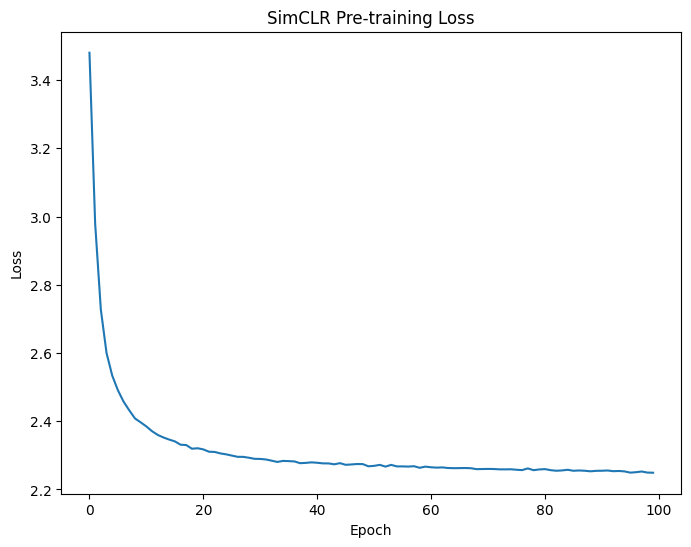

In [137]:
# Plot pre-training loss
plt.figure(figsize=(8, 6))
plt.plot(pretrain_losses)
plt.title('SimCLR Pre-training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('pretrain_loss.png')
plt.show()

In [138]:
# t-SNE Visualization
model.eval()

SimCLR(
  (encoder): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
              (scale_activa

Extracting features for t-SNE: 100%|██████████| 63/63 [00:06<00:00,  9.81it/s]


Running t-SNE on pretrain dataset features...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2000 samples in 0.001s...
[t-SNE] Computed neighbors for 2000 samples in 0.252s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2000
[t-SNE] Computed conditional probabilities for sample 2000 / 2000
[t-SNE] Mean sigma: 8.470388
[t-SNE] KL divergence after 250 iterations with early exaggeration: 64.891495
[t-SNE] KL divergence after 1000 iterations: 0.628558


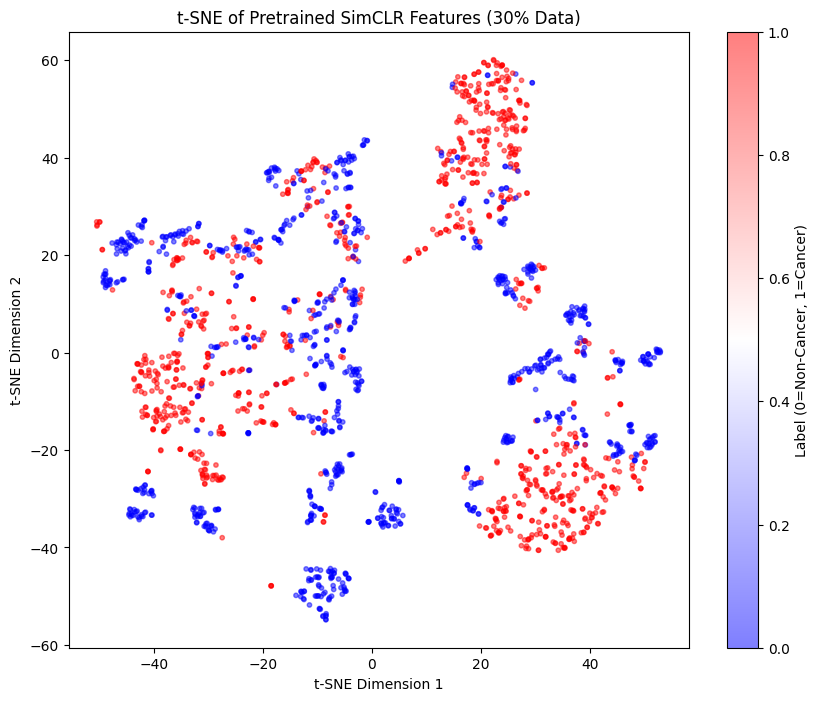

t-SNE plot saved as 'tsne_simclr_pretrain.png'


In [139]:
# Use base_dataset subset for t-SNE (PIL, then transform)
tsne_subset = torch.utils.data.Subset(base_dataset, pretrain_indices)
tsne_wrapper = DownstreamWrapper(tsne_subset, transform=downstream_transform)
tsne_loader = DataLoader(tsne_wrapper, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

features = []
labels = []
with torch.no_grad():
    for batch in tqdm(tsne_loader, desc="Extracting features for t-SNE"):
        img, label = batch  # Single img
        img = img.to(device)
        feature = model.encoder(img)
        feature = feature.view(feature.size(0), -1)
        features.append(feature.cpu().numpy())
        labels.append(label.numpy())
features = np.concatenate(features, axis=0)
labels = np.concatenate(labels, axis=0)

print("Running t-SNE on pretrain dataset features...")
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=1)
tsne_features = tsne.fit_transform(features)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_features[:, 0], tsne_features[:, 1], c=labels, cmap='bwr', alpha=0.5, s=10)
plt.colorbar(scatter, label='Label (0=Non-Cancer, 1=Cancer)')
plt.title('t-SNE of Pretrained SimCLR Features (30% Data)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.savefig('tsne_simclr_pretrain.png')
plt.show()
print("t-SNE plot saved as 'tsne_simclr_pretrain.png'")

In [140]:
# Downstream classification with SVM
num_epochs_cls = 100
# Extract features from pre-trained encoder
model.eval()
train_features, train_labels = [], []
with torch.no_grad():
    for img, label in train_loader_downstream:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        train_features.append(feature)
        train_labels.append(label.numpy())
train_features = np.concatenate(train_features, axis=0)
train_labels = np.concatenate(train_labels, axis=0)

val_features, val_labels = [], []
with torch.no_grad():
    for img, label in val_loader_downstream:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        val_features.append(feature)
        val_labels.append(label.numpy())
val_features = np.concatenate(val_features, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

# Train SVM
from sklearn.svm import SVC
svm_classifier = SVC(kernel='rbf', random_state=42, probability=True)
svm_classifier.fit(train_features, train_labels)

# Validate
val_pred = svm_classifier.predict(val_features)
val_acc = (val_pred == val_labels).mean()
print(f"Validation Accuracy: {val_acc:.4f}")

Validation Accuracy: 0.8538


In [141]:
# Test evaluation
test_features, test_labels = [], []
with torch.no_grad():
    for img, label in test_loader:
        img = img.to(device)
        feature = model.encoder(img).view(img.size(0), -1).cpu().numpy()
        test_features.append(feature)
        test_labels.append(label.numpy())
test_features = np.concatenate(test_features, axis=0)
test_labels = np.concatenate(test_labels, axis=0)

test_pred = svm_classifier.predict(test_features)
test_acc = (test_pred == test_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8448


In [142]:
# Import necessary libraries for visualizations
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

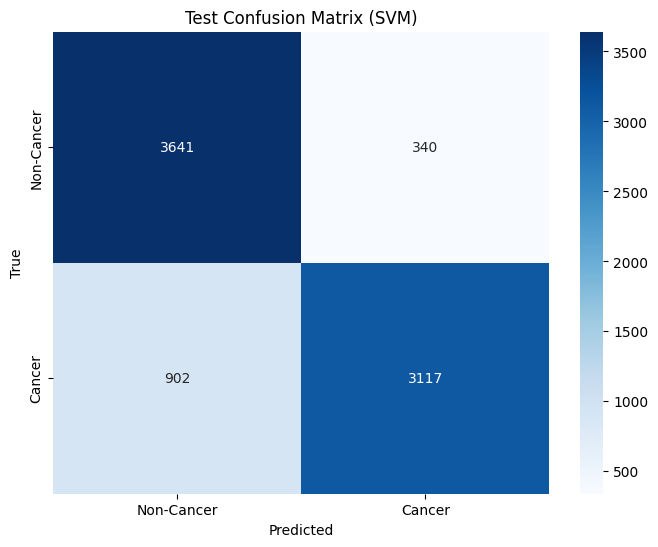

In [143]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Cancer', 'Cancer'], yticklabels=['Non-Cancer', 'Cancer'])
plt.title('Test Confusion Matrix (SVM)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.savefig('test_cm_svm.png')
plt.show()

In [144]:
# Classification report
print(classification_report(test_labels, test_pred, target_names=['Non-Cancer', 'Cancer']))

              precision    recall  f1-score   support

  Non-Cancer       0.80      0.91      0.85      3981
      Cancer       0.90      0.78      0.83      4019

    accuracy                           0.84      8000
   macro avg       0.85      0.85      0.84      8000
weighted avg       0.85      0.84      0.84      8000



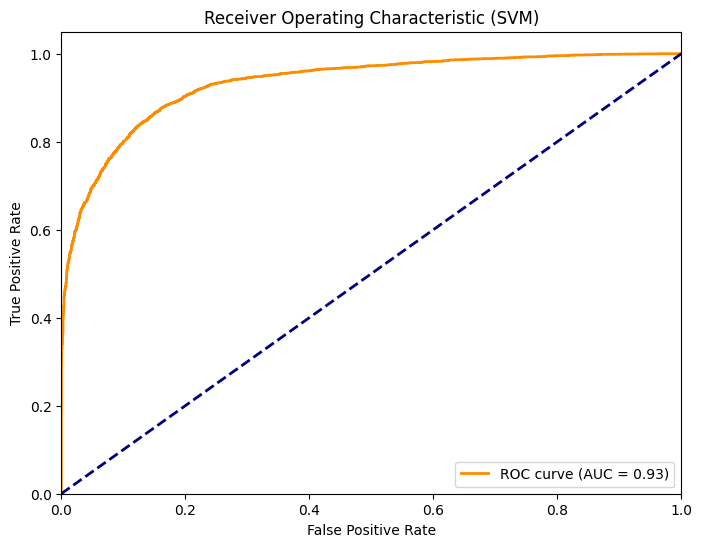

In [145]:
# ROC Curve
test_prob = svm_classifier.predict_proba(test_features)[:, 1]  # Probability for the positive class (Cancer)
fpr, tpr, _ = roc_curve(test_labels, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (SVM)')
plt.legend(loc='lower right')
plt.savefig('roc_curve_svm.png')
plt.show()

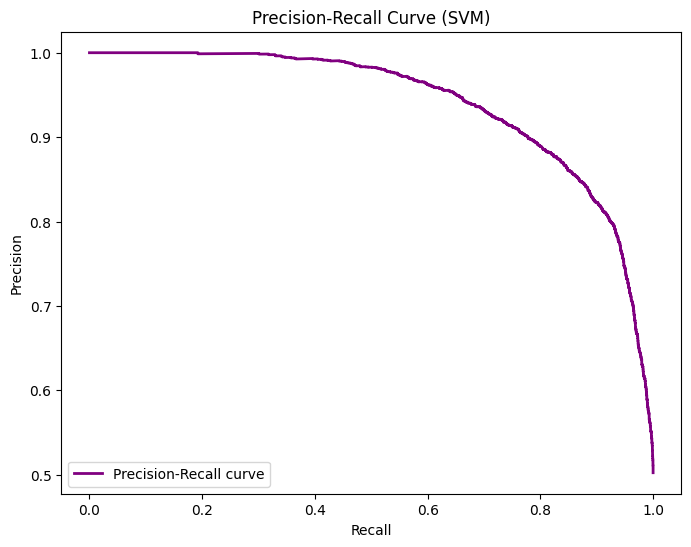

In [146]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(test_labels, test_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (SVM)')
plt.legend(loc='lower left')
plt.savefig('pr_curve_svm.png')
plt.show()

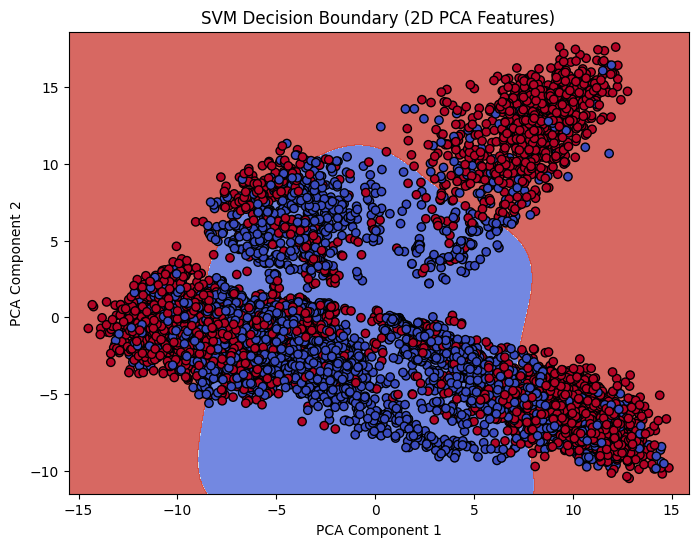

In [147]:
# Optional: Decision Boundary (requires 2D features via t-SNE or PCA)
from sklearn.decomposition import PCA
# Reduce features to 2D using PCA
pca = PCA(n_components=2)
test_features_2d = pca.fit_transform(test_features)

# Train SVM on 2D features
svm_2d = SVC(kernel='rbf', random_state=42)
svm_2d.fit(test_features_2d, test_labels)

# Create mesh grid for decision boundary
h = 0.02  # Step size in the mesh
x_min, x_max = test_features_2d[:, 0].min() - 1, test_features_2d[:, 0].max() + 1
y_min, y_max = test_features_2d[:, 1].min() - 1, test_features_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict on mesh grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(test_features_2d[:, 0], test_features_2d[:, 1], c=test_labels, cmap=plt.cm.coolwarm, edgecolors='k')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('SVM Decision Boundary (2D PCA Features)')
plt.savefig('decision_boundary_svm.png')
plt.show()